========== Simulation Summary ==========
Be bar radius          = 0.630 cm
Scatter grid step      = 0.300 cm
Number of scatter pts  = 308
Number of phi bins     = 36
Number of pixels       = 1024


>>>>>>>> Test energy: 15 keV | PSF sigma: 0.180 | lambda: 2.152 cm <<<<<<<<


>>>>>>>> Test energy: 20 keV | PSF sigma: 0.180 | lambda: 2.849 cm <<<<<<<<


>>>>>>>> Test energy: 30 keV | PSF sigma: 0.180 | lambda: 3.347 cm <<<<<<<<


>>>>>>>> Test energy: 40 keV | PSF sigma: 0.180 | lambda: 3.524 cm <<<<<<<<


>>>>>>>> Test energy: 50 keV | PSF sigma: 0.180 | lambda: 3.640 cm <<<<<<<<


>>>>>>>> Test energy: 60 keV | PSF sigma: 0.180 | lambda: 3.743 cm <<<<<<<<


>>>>>>>> Test energy: 80 keV | PSF sigma: 0.180 | lambda: 3.940 cm <<<<<<<<


>>>>>>>> Test energy: 100 keV | PSF sigma: 0.180 | lambda: 4.126 cm <<<<<<<<
Normalization check    = 1.000000

Top 12 pixels:
pixel 97 : 0.003382
pixel 897 : 0.003382
pixel 129 : 0.003353
pixel 865 : 0.003353
pixel 98 : 0.003168
pixel 898 : 0.003168
pixel

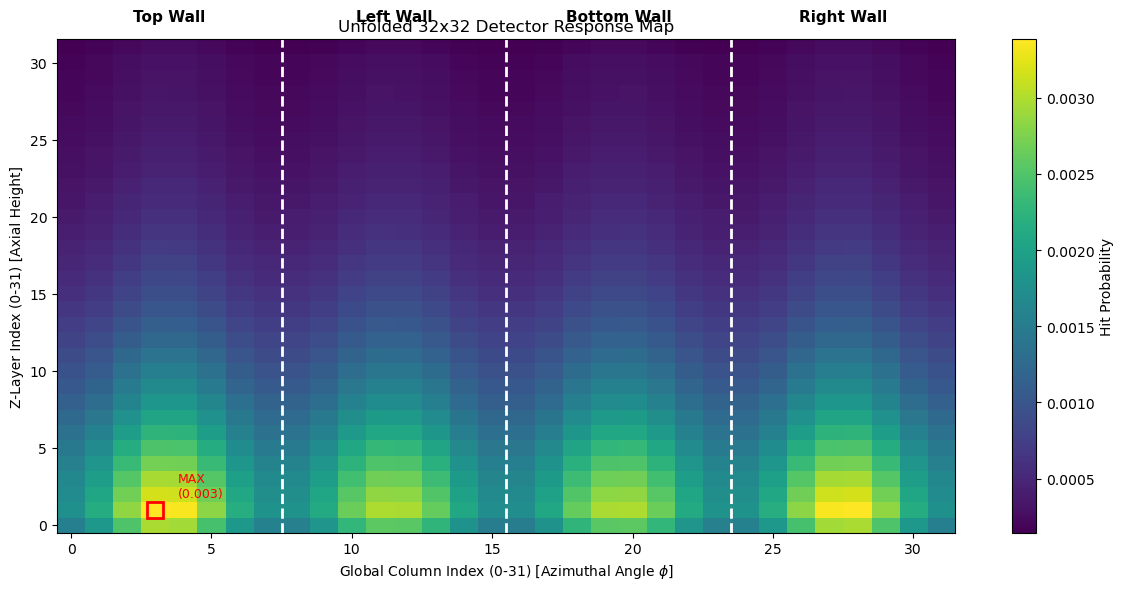

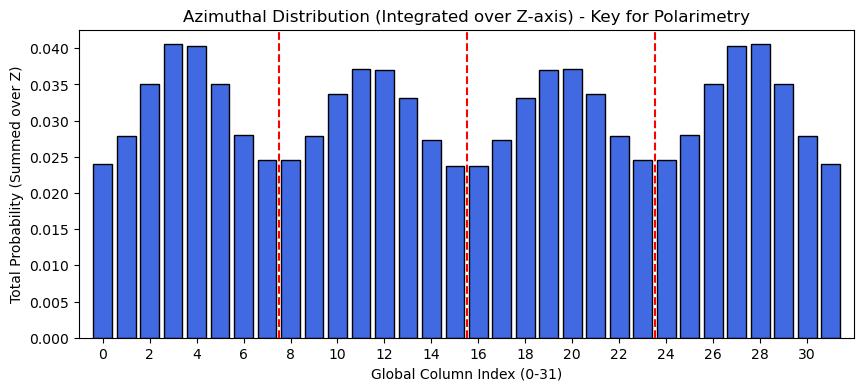


========== Example Ray ==========
scatter point = (0.5, 0.0, 0.0)
phi (deg)     = 25.00
hit point     = (1.0000, 0.2332, 0.0000)
hit side      = right
hard pixel    = 880
Top 6 pixels for this one ray:
pixel 880 : 0.201407
pixel 879 : 0.201407
pixel 848 : 0.176857
pixel 847 : 0.176857
pixel 912 : 0.033325
pixel 911 : 0.033325

Top 8 pixels for center-point response:
pixel 879 : 0.014290
pixel 911 : 0.014290
pixel 912 : 0.014290
pixel 880 : 0.014290
pixel 910 : 0.009758
pixel 913 : 0.009758
pixel 881 : 0.009758
pixel 878 : 0.009758


In [4]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Geometry definition

R = 0.63                      # Be bar radius (cm)
bar_center = (0.0, 0.0)
L_half = 4.0 # The half length of the beryllium rod

square_min = -1.0
square_max =  1.0

n_pixels_per_side = 8
n_total_pixels = 4 * n_pixels_per_side
side_length = square_max - square_min
pixel_size = side_length / n_pixels_per_side
n_layers_z = 32

# PSF width: detector resolution, kept constant across photon energy
sigma_psf = 0.18

# ( phi + theta) angular sampling  
n_phi = 36
phi_values = np.linspace(0, 2*np.pi, n_phi, endpoint=False)

n_theta = 18
cos_theta = np.linspace(-1, 1, n_theta)
theta_values = np.arccos(cos_theta)

# scatter grid spacing
grid_step = 0.3

# Energy-dependent Be attenuation data
be_density = 1.85 # g/cm^3

# energy：mass attenuation coefficien
attenuation_data = {
    15: 0.2512,  # cm^2/g, 1.500E-02 MeV
    20: 0.1897,
    30: 0.1615,
    40: 0.1534,
    50: 0.1485,
    60: 0.1444,
    80: 0.1372,
    100: 0.1310,
}

scattering_fraction_data = {
    15: {"coherent": 5.580e-2, "incoherent": 1.411e-1, "total_with_coherent": 3.070e-1},
    20: {"coherent": 3.538e-2, "incoherent": 1.477e-1, "total_with_coherent": 2.251e-1},
    30: {"coherent": 1.770e-2, "incoherent": 1.508e-1, "total_with_coherent": 1.792e-1},
    40: {"coherent": 1.054e-2, "incoherent": 1.493e-1, "total_with_coherent": 1.640e-1},
    50: {"coherent": 6.956e-3, "incoherent": 1.465e-1, "total_with_coherent": 1.554e-1},
    60: {"coherent": 4.920e-3, "incoherent": 1.433e-1, "total_with_coherent": 1.493e-1},
    80: {"coherent": 2.823e-3, "incoherent": 1.369e-1, "total_with_coherent": 1.401e-1},
    100: {"coherent": 1.824e-3, "incoherent": 1.308e-1, "total_with_coherent": 1.328e-1},
}

def get_mu_at_energy(energy_keV):
    energies = np.array(sorted(attenuation_data.keys()), dtype=float)
    coeffs = np.array([attenuation_data[E] for E in energies], dtype=float) # mass attenuation coefficien
    mass_coeff = np.interp(energy_keV, energies, coeffs) # if can not find the exact energy, interpolate between the two nearest energies
    return mass_coeff * be_density # get mu(E)    cm^2/g * g/cm^3 = 1/cm

def get_lambda_at_energy(energy_keV):
    return 1.0 / get_mu_at_energy(energy_keV) # lambda = 1/mu

def get_scattering_fraction_at_energy(energy_keV):

    energies = np.array(sorted(scattering_fraction_data.keys()), dtype=float)

    coherent = np.array([scattering_fraction_data[E]["coherent"] for E in energies], dtype=float)

    incoherent = np.array([scattering_fraction_data[E]["incoherent"] for E in energies], dtype=float)

    total = np.array([scattering_fraction_data[E]["total_with_coherent"] for E in energies], dtype=float)

    coherent_E = np.interp(energy_keV, energies, coherent)

    incoherent_E = np.interp(energy_keV, energies, incoherent)

    total_E = np.interp(energy_keV, energies, total)

    return (coherent_E + incoherent_E) / total_E



def scatter_weight_at_energy(x0, y0, z0, energy_keV):
    # incoming photons travel along +z from z = -L_half.
    mu = get_mu_at_energy(energy_keV)
    depth = z0 + L_half
    scattering_fraction = get_scattering_fraction_at_energy(energy_keV)

    return mu * np.exp(-mu * depth) * scattering_fraction


# 2. Build detector pixels on a square boundary
#    Pixel ordering:
#      0-255: top
#      256-511: left
#      512-767: bottom
#      768-1023: right


def build_pixels(square_min, square_max, L_half, n_pixels_per_side, n_layers_z):
    pixels = []
    pixel_size_xy = (square_max - square_min) / n_pixels_per_side # 2cm/ 8 pixles
    pixel_size_z = (2.0 * L_half) / n_layers_z # 8cm /32 pixles

    z_centers = [(-L_half + (j + 0.5) * pixel_size_z) for j in range(n_layers_z)]

    #  Top side: y = square_max 
    for i in range(n_pixels_per_side):
        x_center = square_min + (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z): 
            pixels.append({
                "pixel_id": len(pixels),
                "side": "top",
                "column_idx": i,
                "layer_idx": j,
                "x_center": x_center,
                "y_center": square_max,
                "z_center": z_centers[j]
            })

    #  Left wall: x = square_min 
    for i in range(n_pixels_per_side):
        y_center = square_max - (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "left",
                "column_idx": i,
                "layer_idx": j,
                "x_center": square_min,
                "y_center": y_center,
                "z_center": z_centers[j]
            })

    #  Bottom wall: y = square_min 
    for i in range(n_pixels_per_side):
        x_center = square_min + (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "bottom",
                "column_idx": i,
                "layer_idx": j,
                "x_center": x_center,
                "y_center": square_min,
                "z_center": z_centers[j]
            })

    # Right wall: x = square_max 
    for i in range(n_pixels_per_side):
        y_center = square_max - (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "right",
                "column_idx": i,
                "layer_idx": j,
                "x_center": square_max,
                "y_center": y_center,
                "z_center": z_centers[j]
            })

    return pixels


pixels = build_pixels(square_min, square_max, L_half, n_pixels_per_side, n_layers_z)


# 3. Build a scatter grid inside a circular Be bar

#### update from 2D to 3D
def build_scatter_points(R, L_half, grid_step):
    scatter_points = []
    x_vals = np.arange(-R, R + grid_step, grid_step) #np.arange(start, stop, step)
    y_vals = np.arange(-R, R + grid_step, grid_step)
    z_vals = np.arange(-L_half, L_half + grid_step, grid_step)

    for x in x_vals:
        for y in y_vals:
            if x*x + y*y <= R*R:
                for z in z_vals:
                    scatter_points.append((x, y, z))
    return scatter_points


scatter_points = build_scatter_points(R, L_half, grid_step)



# 4. Trace a ray from (x0, y0) along direction phi
#    to the first hit point on the square boundary

def trace_ray_to_square(x0, y0, z0, phi, theta, square_min, square_max, L_half, eps=1e-12):
    dx = np.sin(theta) * np.cos(phi)
    dy = np.sin(theta) * np.sin(phi)
    dz = np.cos(theta)
    # direction of photon emission (dx, dy, dz)
    t_candidates = []

    # vertical boundaries
    if abs(dx) > eps:
        # x = square_max (right wall)
        t_right = (square_max - x0) / dx
        if t_right > 0:
            y_right = y0 + t_right * dy # y and z coordinates when the photon hits the x boundary
            z_right = z0 + t_right * dz
            if (square_min - eps <= y_right <= square_max + eps) and (abs(z_right) <= L_half + eps):
                t_candidates.append((t_right, square_max, y_right, z_right, "right"))

        # x = square_min (left wall)
        t_left = (square_min - x0) / dx
        if t_left > 0:
            y_left = y0 + t_left * dy
            z_left = z0 + t_left * dz
            if (square_min - eps <= y_left <= square_max + eps) and (abs(z_left) <= L_half + eps):
                t_candidates.append((t_left, square_min, y_left, z_left, "left"))

    # horizontal boundaries
    if abs(dy) > eps:
        # y = square_max (top wall)
        t_top = (square_max - y0) / dy
        if t_top > 0:
            x_top = x0 + t_top * dx
            z_top = z0 + t_top * dz
            if (square_min - eps <= x_top <= square_max + eps) and (abs(z_top) <= L_half + eps):
                t_candidates.append((t_top, x_top, square_max, z_top, "top"))

        # y = square_min (bottom wall)
        t_bottom = (square_min - y0) / dy
        if t_bottom > 0:
            x_bottom = x0 + t_bottom * dx
            z_bottom = z0 + t_bottom * dz
            if (square_min - eps <= x_bottom <= square_max + eps) and (abs(z_bottom) <= L_half + eps):
                t_candidates.append((t_bottom, x_bottom, square_min, z_bottom, "bottom"))

    if len(t_candidates) == 0:
        return None

    t_hit, x_hit, y_hit, z_hit, hit_side = min(t_candidates, key=lambda item: item[0])
    return x_hit, y_hit, z_hit, hit_side



# 5. Hard assignment: hit point -> pixel ID
#    (kept for checking/debugging)

def hit_to_pixel_id(x_hit, y_hit, z_hit, hit_side,
                    square_min, square_max, L_half,
                    n_pixels_per_side, n_layers_z):
    pixel_size_xy = (square_max - square_min) / n_pixels_per_side
    pixel_size_z = (2.0 * L_half) / n_layers_z
    z_min = -L_half

    z_layer_idx = int((z_hit - z_min) / pixel_size_z)   # photon strikes the # z-layer
    if z_layer_idx < 0: z_layer_idx = 0                 
    if z_layer_idx >= n_layers_z: z_layer_idx = n_layers_z - 1

    pixels_per_wall = n_pixels_per_side * n_layers_z # 8*32 = 256 pixels per side wall

    if hit_side == "top":   # ID = 0-255
        col_idx = int((x_hit - square_min) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1 # Prevent "cornering" type of boundary violation crashes
        wall_offset = 0 * pixels_per_wall

    elif hit_side == "left": # ID = 256-511
        col_idx = int((square_max - y_hit) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 1 * pixels_per_wall

    elif hit_side == "bottom": # ID = 512-767
        col_idx = int((x_hit - square_min) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 2 * pixels_per_wall

    elif hit_side == "right": # ID = 768-1023
        col_idx = int((square_max - y_hit) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 3 * pixels_per_wall

    else:
        return None

    hard_pixel = wall_offset + col_idx * n_layers_z + z_layer_idx
    
    return hard_pixel




#  PSF weighting to all pixels
#    polsim-like Gaussian idea:
#        weight ~ exp(-dist2 / (2*sigma^2))


def psf_weights_to_pixels(x_hit, y_hit, z_hit, pixels, sigma):
    weights = []

    for p in pixels:
        dx = p["x_center"] - x_hit
        dy = p["y_center"] - y_hit
        dz = p["z_center"] - z_hit
        dist2 = dx*dx + dy*dy + dz*dz
        w = np.exp(-dist2 / (2.0 * sigma * sigma))
        weights.append(w)

    weights = np.array(weights, dtype=float)

    if weights.sum() > 0:
        weights /= weights.sum()

    return weights



# 7. One-ray response:
#       (x0, y0, phi) -> probability over 32 pixels

def ray_response(x0, y0, z0, phi, theta, pixels, sigma):
    result = trace_ray_to_square(x0, y0, z0, phi, theta, square_min, square_max, L_half, eps=1e-12)
    if result is None:
        return np.zeros(len(pixels), dtype=float)

    x_hit, y_hit, z_hit, hit_side = result
    return psf_weights_to_pixels(x_hit, y_hit, z_hit, pixels, sigma)



# 8. One-point response:
#       fixed (x0, y0, z0), integrate over all phi and theta

def point_response_over_angles(x0, y0, z0, phi_values, theta_values, pixels, sigma):
    total_probs = np.zeros(len(pixels), dtype=float)

    for phi in phi_values:
        for theta in theta_values:
            total_probs += ray_response(x0, y0, z0, phi, theta, pixels, sigma)

    if total_probs.sum() > 0:
        total_probs /= total_probs.sum()

    return total_probs



# 9. Full Be bar response:
#       integrate over all scatter points


def total_response_over_bar(scatter_points, phi_values, theta_values, pixels, sigma, energy_keV=None):
    total_probs = np.zeros(len(pixels), dtype=float) #1024 pixels

    for (x0, y0, z0) in scatter_points:
        point_probs = point_response_over_angles(x0, y0, z0, phi_values, theta_values, pixels, sigma)
        if energy_keV is None:
            scatter_weight = 1.0
        else:
            scatter_weight = scatter_weight_at_energy(x0, y0, z0, energy_keV)
        total_probs += scatter_weight * point_probs

    if total_probs.sum() > 0:
        total_probs /= total_probs.sum()

    return total_probs



# 10. Run the full simulation

energies_to_test = [15, 20, 30, 40, 50, 60, 80, 100]
results = {}

spectrum_T = 1.65 # Cyg X-1; use 2.15 for Crab

spectrum_weighted_probs = np.zeros(len(pixels), dtype=float)

spectrum_weight_sum = 0.0

print("========== Simulation Summary ==========")
print(f"Be bar radius          = {R:.3f} cm")
print(f"Scatter grid step      = {grid_step:.3f} cm")
print(f"Number of scatter pts  = {len(scatter_points)}")
print(f"Number of phi bins     = {len(phi_values)}")
print(f"Number of pixels       = {len(pixels)}")


for E in energies_to_test:
    lambda_E = get_lambda_at_energy(E)
    print(f"\n\n>>>>>>>> Test energy: {E} keV | PSF sigma: {sigma_psf:.3f} | lambda: {lambda_E:.3f} cm <<<<<<<<")

    total_probs = total_response_over_bar(
        scatter_points=scatter_points,
        phi_values=phi_values,
        theta_values=theta_values,
        pixels=pixels,
        sigma=sigma_psf,
        energy_keV=E
    )

    results[E] = total_probs

    spectrum_weight = E ** (-spectrum_T)

    spectrum_weighted_probs += spectrum_weight * total_probs

    spectrum_weight_sum += spectrum_weight

if spectrum_weight_sum > 0:

    total_probs = spectrum_weighted_probs / spectrum_weight_sum
    
print(f"Normalization check    = {total_probs.sum():.6f}")

print("\nTop 12 pixels:")
top_ids = np.argsort(total_probs)[::-1][:12]
for pid in top_ids:
    print(f"pixel {pid:2d} : {total_probs[pid]:.6f}")

top_sum    = total_probs[0:256].sum()
left_sum   = total_probs[256:512].sum()
bottom_sum = total_probs[512:768].sum()
right_sum  = total_probs[768:1024].sum()

print("\nSide totals:")
print(f"top    = {top_sum:.6f}")
print(f"left   = {left_sum:.6f}")
print(f"bottom = {bottom_sum:.6f}")
print(f"right  = {right_sum:.6f}")



# 11. Plot geometry + highlight strongest pixels

'''fig, ax = plt.subplots(figsize=(8, 8))

# Be bar
circle = plt.Circle(bar_center, R, fill=False, linewidth=2, color='blue')
ax.add_patch(circle)

# square detector boundary
ax.plot([-1,  1], [ 1,  1], 'k-')
ax.plot([-1, -1], [ 1, -1], 'k-')
ax.plot([-1,  1], [-1, -1], 'k-')
ax.plot([ 1,  1], [ 1, -1], 'k-')

# scatter grid
scatter_x = [pt[0] for pt in scatter_points]
scatter_y = [pt[1] for pt in scatter_points]
ax.plot(scatter_x, scatter_y, 'b.', markersize=3, alpha=0.20)

# pixel centers + labels
for p in pixels:
    ax.plot(p["x_center"], p["y_center"], 'ro', markersize=4)
    ax.text(p["x_center"], p["y_center"], str(p["pixel_id"]), fontsize=7)

# highlight top-response pixels
top_ids = np.argsort(total_probs)[::-1][:12]
for pid in top_ids:
    px = pixels[pid]["x_center"]
    py = pixels[pid]["y_center"]
    ax.plot(px, py, 'cs', markersize=8)
    ax.text(px, py + 0.05, f"{total_probs[pid]:.2f}", fontsize=8, color='c')

ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_title("Total detector response over whole Be bar")
plt.show()
'''
# # 11. Plot 3D Unfolded Detector Map 
response_matrix = total_probs.reshape(32, 32).T

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(response_matrix, origin='lower', aspect='auto', cmap='viridis')


cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Hit Probability')

for x_line in [7.5, 15.5, 23.5]:
    ax.axvline(x=x_line, color='white', linestyle='--', linewidth=2)

wall_names = ["Top Wall", "Left Wall", "Bottom Wall", "Right Wall"]
for i, name in enumerate(wall_names):
    ax.text(i * 8 + 3.5, 32.5, name, color='black', ha='center', va='bottom', 
            fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Highlight the 1 pixel that receives the maximum amount of energy (the brightest one)
max_idx = np.argmax(total_probs)
max_col = max_idx // 32  
max_layer = max_idx % 32 
ax.plot(max_col, max_layer, 'rs', markersize=12, fillstyle='none', markeredgewidth=2)
ax.text(max_col + 0.8, max_layer + 0.8, f"MAX\n({total_probs[max_idx]:.3f})", color='red', fontsize=9)


ax.set_xlabel("Global Column Index (0-31) [Azimuthal Angle $\\phi$]")
ax.set_ylabel("Z-Layer Index (0-31) [Axial Height]")
ax.set_title("Unfolded 32x32 Detector Response Map")
ax.set_ylim(-0.5, 31.5)
ax.set_xlim(-0.5, 31.5)

plt.tight_layout()
plt.show()




# Azimuthal Modulation

azimuthal_probs = np.sum(response_matrix, axis=0) 

plt.figure(figsize=(10, 4))
plt.bar(np.arange(32), azimuthal_probs, color='royalblue', edgecolor='black')


for x_line in [7.5, 15.5, 23.5]:
    plt.axvline(x=x_line, color='red', linestyle='--', linewidth=1.5)

plt.xlabel("Global Column Index (0-31)")
plt.ylabel("Total Probability (Summed over Z)")
plt.title("Azimuthal Distribution (Integrated over Z-axis) - Key for Polarimetry")
plt.xlim(-1, 32)
plt.xticks(np.arange(0, 32, 2))
plt.show()

'''
# 12. Plot full probability over 1024 pixels

plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(pixels)), total_probs)
plt.xlabel("Pixel ID")
plt.ylabel("Probability")
plt.title("Total response over  pixels")
plt.show()
'''


# 13. Optional: one example ray and one example point

example_point = (0.5, 0.0, 0.0)
example_phi = np.deg2rad(25.0)
example_theta = np.pi / 2.0
test_sigma = sigma_psf

result = trace_ray_to_square(example_point[0], example_point[1], example_point[2], 
                             example_phi, example_theta, square_min, square_max, L_half)

if result is not None:
    x_hit, y_hit, z_hit, hit_side = result
    hard_pixel = hit_to_pixel_id(x_hit, y_hit, z_hit, hit_side,
                                 square_min, square_max, L_half, n_pixels_per_side, n_layers_z)
    ray_probs = psf_weights_to_pixels(x_hit, y_hit, z_hit, pixels, sigma = test_sigma)

    print("\n========== Example Ray ==========")
    print(f"scatter point = {example_point}")
    print(f"phi (deg)     = {np.degrees(example_phi):.2f}")
    print(f"hit point     = ({x_hit:.4f}, {y_hit:.4f}, {z_hit:.4f})")
    print(f"hit side      = {hit_side}")
    print(f"hard pixel    = {hard_pixel}")

    top_ray_ids = np.argsort(ray_probs)[::-1][:6]
    print("Top 6 pixels for this one ray:")
    for pid in top_ray_ids:
        print(f"pixel {pid:2d} : {ray_probs[pid]:.6f}")

    point_probs = point_response_over_angles(
        example_point[0], example_point[1], example_point[2], 
        phi_values, theta_values, pixels, sigma = test_sigma
    )

    top_point_ids = np.argsort(point_probs)[::-1][:8]
    print("\nTop 8 pixels for center-point response:")
    for pid in top_point_ids:
        print(f"pixel {pid:2d} : {point_probs[pid]:.6f}")